<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/08_%E1%84%83%E1%85%A1%E1%86%AB%E1%84%87%E1%85%A2%E1%86%A8%E1%84%8C%E1%85%B5%E1%86%AF%E1%84%80%E1%85%AE%E1%84%8C%E1%85%A9%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8_AlphaFold_ESMFold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 08 · 단백질 구조 예측 (AlphaFold / ESMFold)
### 아미노산 서열만으로 3D 구조를 예측하는 AI

단백질의 **3D 구조**를 알면 약이 붙을 자리(pocket)를 알 수 있어 신약설계에 필수입니다.
과거엔 구조 하나 밝히는 데 수개월이 걸렸지만,
**AlphaFold2**(DeepMind)가 이를 **몇 분시간**으로 단축했습니다 (2024 노벨화학상).
**ESMFold**(Meta)는 더 빠른 대안으로, **API 호출 한 번**으로 구조를 얻을 수 있습니다.

**이 노트북에서 배우는 것**
- 단백질 서열(아미노산) 개념
- **ESMFold** 로 서열 → 3D 구조 예측 (즉시 실행)
- 예측 신뢰도(pLDDT) 해석
- **AlphaFold(ColabFold)** 사용법


In [1]:
!pip install biopython py3Dmol requests -q
import requests, py3Dmol
print("준비 완료 ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.3 MB/s eta 0:00:00
준비 완료 ✅


## 1. 단백질 서열이란?
단백질은 20종 아미노산이 이어진 사슬입니다 (각 문자가 아미노산 하나).
예로 **인슐린 A사슬**(21개 아미노산) 같은 짧은 서열로 시작합니다.


In [2]:
# 짧은 예제 단백질: villin headpiece (HP36), 잘 접히는 소형 도메인
seq = "MLSDEDFKAVFGMTRSAFANLPLWKQQNLKKEKGLF"
print("서열 길이:", len(seq), "아미노산")
print("서열:", seq)

서열 길이: 36 아미노산
서열: MLSDEDFKAVFGMTRSAFANLPLWKQQNLKKEKGLF


## 2. ⭐ ESMFold API 로 구조 예측
Meta 의 **ESMFold** 는 공개 API 로 서열을 보내면 **PDB 구조**를 돌려줍니다.
(AlphaFold 처럼 방대한 DB 검색이 필요 없어 매우 빠름 — 작은 단백질에 이상적)
- Evolutionary Scale Modeling


In [3]:
# ESMFold 공개 API 호출 (서열 → PDB 3D 좌표) # 'requests' API를 요청하는것(?)
resp = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/",
                     data=seq, verify=False, timeout=120)
if resp.status_code == 200 and resp.text.startswith(("HEADER","ATOM","MODEL")):
    pdb = resp.text
    open("predicted.pdb","w").write(pdb)
    print("구조 예측 성공 ✅  (원자 수:", pdb.count("ATOM "), ")")
else:
    print("API 응답 상태:", resp.status_code)
    print("※ API 혼잡 시 잠시 후 재시도하거나, 아래 ColabFold 섹션을 사용하세요.")
    pdb = None

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.esmatlas.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


구조 예측 성공 ✅  (원자 수: 294 )


In [4]:
# 예측된 3D 구조를 인터랙티브하게 시각화 (마우스로 회전 가능)
if pdb:
    view = py3Dmol.view(width=650, height=450)
    view.addModel(pdb, "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})   # 리본 다이어그램
    view.zoomTo()
    view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3. 예측 신뢰도 (pLDDT) 해석 — 매우 중요
구조 예측은 **부위마다 신뢰도가 다릅니다**.


**pLDDT**(0~100)가 신뢰도 점수이며
PDB 파일의 B-factor 자리에 저장됩니다. (pLDDT: predicted Local Distance Difference Test)
 - pLDDT는 각 아미노산 잔기 주변의 국소적인 3차원 구조에 대한 신뢰도입니다.

예를 들어 다음을 평가합니다.

- 이 잔기 주변의 주사슬 구조가 정확한가
α-나선이나 β-sheet가 제대로 예측됐는가
주변 잔기들과의 상대적 배치가 믿을 만한가

- pLDDT > 90: 매우 높음 (원자 수준 신뢰)
- 70~90: 높음 (백본 신뢰)
- 50~70: 낮음,
- < 50: 매우 낮음(유연/무질서 영역일 수 있음)

**신약설계에서는 pocket 영역의 pLDDT 가 높은지 반드시 확인**해야 합니다.
- pLDDT는 실제 구조와 비교해 계산한 정확도 점수가 아니라, 모델이 스스로 예측한 confidence score임
- pLDDT는 잔기별 국소 구조 신뢰도이고, 단백질 도메인 간 상대적 배치나 전체 복합체 구조는 PAE(predicted aligned error) 같은 지표를 함께 봐야함


PAE: “두 부분의 상대적 위치가 정확한가?” (PAE: Predicted Aligned Error)
- 잔기 쌍마다 계산되는 값으로, 단위는 보통 **Å**입니다.
- PAE가 낮으면 두 잔기 또는 두 영역의 상대적 위치와 방향을 모델이 신뢰한다는 뜻이고, 높으면 상대 배치가 불확실하다는 뜻입니다.
- DeepMind도 상대적인 도메인 배치를 판단하는 데는 pLDDT보다 PAE가 더 적합하다고 설명합니다.
- pLDDT는 각 구조 부품이 잘 만들어졌는지를 보고, PAE는 그 부품들이 서로 올바른 위치와 방향으로 조립됐는지를 본다.

복합체에서는 PAE와 함께 다음 지표도 확인하는 것이 좋습니다.

- ipTM: 단백질 사슬 사이 인터페이스 신뢰도
- pTM: 전체 구조와 도메인 배치의 전역적 신뢰도
- 인터페이스 잔기의 pLDDT
- 실제 접촉면의 물리·생화학적 타당성

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,810 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


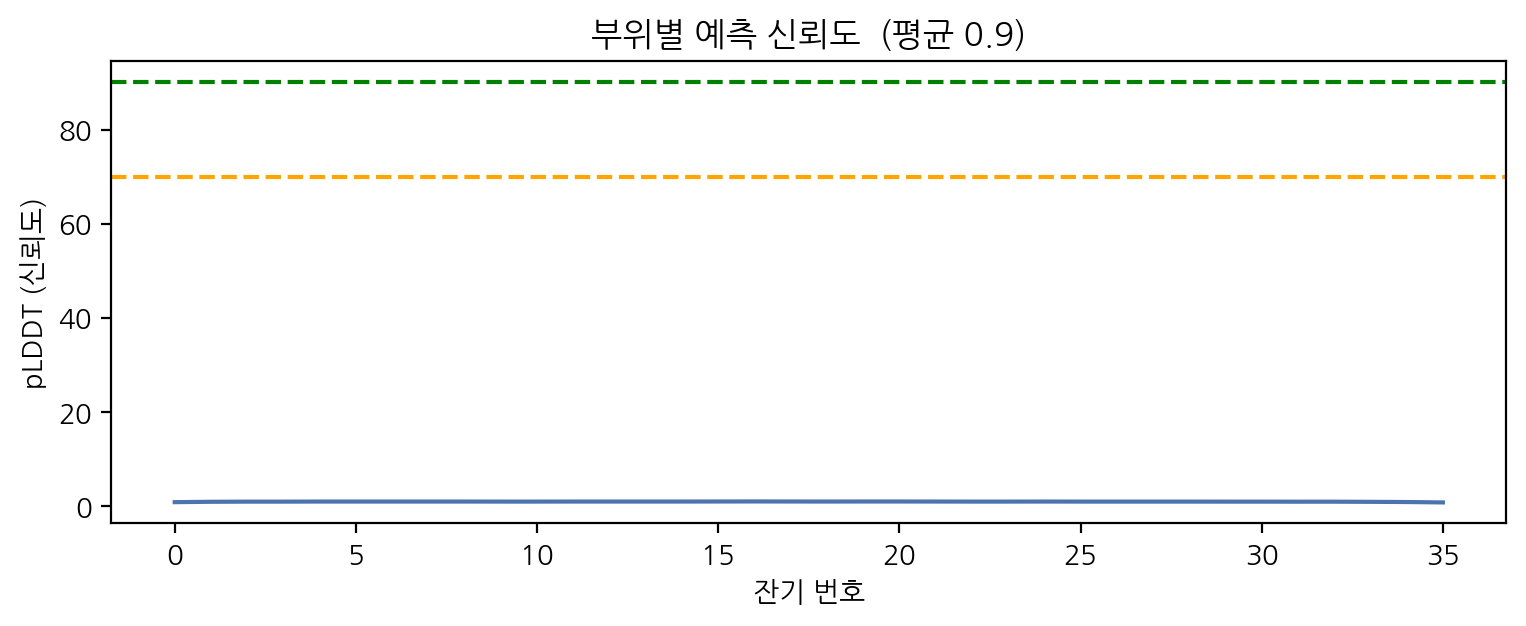

평균 pLDDT: 0.9 → 주의 필요


In [5]:
# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

if pdb:
    import numpy as np
    # 각 잔기의 pLDDT (CA 원자의 B-factor) 추출
    plddt = []
    for line in pdb.split("\n"):
        if line.startswith("ATOM") and line[12:16].strip()=="CA":
            plddt.append(float(line[60:66]))
    plddt = np.array(plddt)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9,3))
    plt.plot(plddt, color="#4C72B0"); plt.axhline(70,color="orange",ls="--")
    plt.axhline(90,color="green",ls="--")
    plt.xlabel("잔기 번호"); plt.ylabel("pLDDT (신뢰도)")
    plt.title(f"부위별 예측 신뢰도  (평균 {plddt.mean():.1f})"); plt.show()
    print("평균 pLDDT:", round(plddt.mean(),1),
          "→", "신뢰 높음" if plddt.mean()>70 else "주의 필요")

## 4. AlphaFold (ColabFold)
**ColabFold** 는 AlphaFold2 를 Colab 에서 쉽게 실행하는 도구입니다.
큰 단백질, 복합체(단백질-단백질), 최고 정확도가 필요할 때 사용합니다.

**사용법 (직접 실행은 별도 노트북에서)**
1. 공식 노트북 열기: **`ColabFold: AlphaFold2_mmseqs2`**
   (구글 검색 "ColabFold GitHub" → `AlphaFold2.ipynb`)
2. 서열 붙여넣기 → [런타임]>모두 실행
3. MSA(다중서열정렬) 생성 → 구조 예측 → pLDDT/PAE 그래프 자동 출력
4. 결과 PDB 다운로드 → 도킹(예제 14)에 사용

| 방법 | 속도 | 정확도 | 적합 상황 |
|---|---|---|---|
| **ESMFold** (이 노트북) | 매우 빠름 | 좋음 | 소형 단백질, 빠른 확인 |
| **ColabFold/AlphaFold2** | 느림(수십분) | 최고 | 정밀 신약설계, 복합체 |
| **AlphaFold3** | - | 최고+리간드 | 단백질-리간드 복합 예측(웹서버) |

> 실무 팁: 이미 실험구조가 있으면 **PDB(rcsb.org)** 에서 받는 게 최선.
> 없을 때 AlphaFold/ESMFold 로 예측 구조를 사용합니다.


In [6]:
# 참고: 이미 밝혀진 실험 구조는 PDB 에서 즉시 다운로드 가능
# 예: BACE-1 단백질 (PDB ID: 1SGZ)
pdb_id = "1SGZ"
r = requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb", timeout=60)
open(f"{pdb_id}.pdb","w").write(r.text)
view = py3Dmol.view(width=650, height=450)
view.addModel(r.text, "pdb")
view.setStyle({"cartoon":{"color":"spectrum"}})
view.zoomTo(); view.show()
print(f"실험으로 밝혀진 {pdb_id} (알츠하이머 표적 BACE-1) 구조 로드 완료")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

실험으로 밝혀진 1SGZ (알츠하이머 표적 BACE-1) 구조 로드 완료


## 정리
- **ESMFold**: API 한 번으로 서열→구조 (빠른 확인용)
- **AlphaFold/ColabFold**: 최고 정확도, 큰 단백질·복합체
- **pLDDT** 로 신뢰도 확인 필수 (특히 결합 pocket 영역)
- 예측/실험 구조는 **도킹** 의 입력이 됨 → 구조 기반 신약설계로 연결
- 제약 적용: 신규 표적 구조 확보, 변이체 영향 분석, 항체 설계
